# Wikipedia Pilot Study - Iteration 3
### Changes from v2
- v3_ file prefix - v2 files untouched
- Same thresholds for both contested and stable (MIN_WORDS=1500, MIN_EDITORS=15)
- Rate limit wait increased to 180s (3 minutes)
- Title cache with 7-day expiry - never re-fetches unnecessarily
- Resume from CSV - if features file exists, skips already processed articles
- Lift Wing topic model for both EN and DE - no keyword map
- Specific topic saved as regression control variable
- No em dashes anywhere in code or output
- Stable articles: Good Articles + verified no dispute history (dual criterion)


## 0. Setup and Imports

In [1]:
# Uncomment if needed:
# !pip install requests pytrends lexicalrichness scikit-learn pandas numpy matplotlib seaborn spacy
# !python -m spacy download en_core_web_sm

import requests, time, json, re, random, os, datetime
from datetime import timezone

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import mannwhitneyu, norm

try:
    from lexicalrichness import LexicalRichness
    LEXRICH_AVAILABLE = True
    print("lexicalrichness loaded")
except:
    LEXRICH_AVAILABLE = False
    print("lexicalrichness not available - MTLD skipped")

try:
    from pytrends.request import TrendReq
    TRENDS_AVAILABLE = True
    print("pytrends loaded")
except:
    TRENDS_AVAILABLE = False
    print("pytrends not available - matching on age + word count only")

HEADERS = {"User-Agent": "UniMannheim-SMDA-Pilot3/1.0 (student research)"}
random.seed(42)
print("Ready")


lexicalrichness loaded
pytrends loaded
Ready


## 1. Configuration - v3

In [2]:
# File names - v3 prefix so v2 files stay untouched
V3_CONTESTED_FILE  = "v3_contested.json"
V3_STABLE_FILE     = "v3_stable_pool.json"
V3_PAIRS_FILE      = "v3_matched_pairs.json"
V3_FEATURES_FILE   = "v3_features.csv"
V3_TRENDS_C_CACHE  = "v3_trends_cache_contested.json"
V3_TRENDS_S_CACHE  = "v3_trends_cache_stable.json"

# Scale
PILOT_CONTESTED   = 50
PILOT_STABLE_POOL = 300

# Article quality thresholds - SAME for both contested and stable
# Rationale: same quality bar ensures comparability
# Stable stability reflects genuine consensus, not low visibility
MIN_WORDS    = 1500   # raised from 1000 - Cyprus Eurovision (1508w) showed 1000 too low
MIN_EDITORS  = 15     # same for both groups
MIN_AGE_DAYS = 365

# Upper word count cap for stable only
# Prevents Featured/Good Articles being 20K word behemoths
MAX_WORDS_STABLE = 8000

# Matching constraints
MAX_MATCH_DISTANCE = 5.0
MAX_AGE_GAP_DAYS   = 730
WORD_COUNT_TOL     = 0.20

# Templates
EN_TEMPLATES = ["Template:POV", "Template:Neutrality"]
VALID_YEARS  = [2022, 2023, 2024, 2025]

# Lift Wing topic broad mapping
TOPIC_BROAD = {
    "STEM":                "science",
    "Culture":             "culture",
    "Geography":           "geography",
    "History_and_Society": "politics_history",
}

print("Config loaded")
print(f"  Min words (both groups) : {MIN_WORDS:,}")
print(f"  Min editors (both)      : {MIN_EDITORS}")
print(f"  Max words (stable only) : {MAX_WORDS_STABLE:,}")
print(f"  Max match distance      : {MAX_MATCH_DISTANCE}")
print(f"  Max age gap (days)      : {MAX_AGE_GAP_DAYS}")
print(f"  Word count tolerance    : +/-{int(WORD_COUNT_TOL*100)}%")
print(f"  Rate limit wait         : 180s (3 minutes)")


Config loaded
  Min words (both groups) : 1,500
  Min editors (both)      : 15
  Max words (stable only) : 8,000
  Max match distance      : 5.0
  Max age gap (days)      : 730
  Word count tolerance    : +/-20%
  Rate limit wait         : 180s (3 minutes)


## 2. Helper Functions

In [3]:
def safe_get(url, params, retries=4, base_wait=3):
    """Robust Wikipedia API GET with retry and rate limit handling."""
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, headers=HEADERS, timeout=20)
            if r.status_code == 429:
                print("    Rate limited - waiting 180s (3 minutes)...")
                time.sleep(180)
                continue
            if r.status_code == 200 and r.text.strip():
                return r.json()
            time.sleep(base_wait * (attempt + 1))
        except Exception as e:
            print(f"    Error: {e}")
            time.sleep(base_wait * (attempt + 1))
    return None


def save_json(data, path):
    """Atomic save - temp file then replace so partial writes never corrupt."""
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def load_json(path, default=None):
    if os.path.exists(path):
        with open(path, encoding="utf-8") as f:
            return json.load(f)
    return default if default is not None else []


def is_recent_dispute(text):
    """Check if POV or Neutrality template was added in a valid year."""
    templates = re.findall(
        r'\{\{(?:POV|Neutrality)[^}]*\}\}', text, re.IGNORECASE)
    for t in templates:
        m = re.search(r'date=\w+ (20\d{2})', t)
        if m and int(m.group(1)) in VALID_YEARS:
            return True
    return False


def clean_wikitext(text):
    """Strip Wikipedia markup and return plain readable text."""
    text = re.sub(r'\{\{[^{}]*\}\}', '', text)
    text = re.sub(r'\[\[(?:[^|\]]*\|)?([^\]]*)\]\]', r'\1', text)
    text = re.sub(r'==+[^=]+=+', '', text)
    text = re.sub(r'<ref[^>]*>.*?</ref>', '', text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r"'{2,}", '', text)
    return re.sub(r'\s+', ' ', text).strip()


def get_topic_liftwing(title, lang, retries=3):
    """
    Get topic using Lift Wing outlink model.
    Works for both EN and DE with same taxonomy.
    Returns (broad_topic, specific_topic).
    Low confidence predictions (score < 0.5) return 'other'.
    """
    url = "https://api.wikimedia.org/service/lw/inference/v1/models/outlink-topic-model:predict"

    for attempt in range(retries):
        try:
            r = requests.post(url,
                headers={**HEADERS, "Content-Type": "application/json"},
                json={"page_title": title, "lang": lang},
                timeout=15
            )
            if r.status_code == 200:
                results = r.json()["prediction"]["results"]
                if not results:
                    return "other", None
                top = max(results, key=lambda x: x["score"])
                if top["score"] < 0.5:
                    return "other", top["topic"]
                specific = top["topic"]
                prefix = specific.split(".")[0]
                broad = TOPIC_BROAD.get(prefix, "other")
                return broad, specific
            time.sleep(2 * (attempt + 1))
        except Exception as e:
            time.sleep(2 * (attempt + 1))

    return "other", None


def get_trends(title, cache):
    """Fetch Google Trends score with caching."""
    if not TRENDS_AVAILABLE:
        return None
    if title in cache:
        return cache[title]
    try:
        pt = TrendReq(hl='en-US', tz=360)
        pt.build_payload([title], timeframe='today 12-m', geo='')
        df = pt.interest_over_time()
        val = round(df[title].mean(), 1) if not df.empty and title in df else None
        cache[title] = val
        return val
    except:
        cache[title] = None
        return None

print("Helper functions ready")


Helper functions ready


## 3. Article Fetch Function

In [4]:
def fetch_article(title, label, lang="en"):
    """
    Fetch full article data.
    label=0 = contested (applies date filter)
    label=1 = stable (applies max word cap, stricter dispute check)
    Same MIN_WORDS and MIN_EDITORS for both groups.
    Returns dict or None if article fails any filter.
    """
    url = f"https://{lang}.wikipedia.org/w/api.php"

    # Text and categories
    d1 = safe_get(url, {
        "action": "query", "titles": title,
        "prop": "revisions|categories",
        "rvprop": "content|timestamp", "rvslots": "main",
        "rvlimit": 1, "cllimit": 50, "format": "json"
    })
    if not d1: return None
    page = list(d1["query"]["pages"].values())[0]
    if "revisions" not in page: return None

    raw = page["revisions"][0]["slots"]["main"]["*"]
    wc  = len(raw.split())

    # Same word count floor for both groups
    if wc < MIN_WORDS: return None

    # Upper cap for stable only
    if label == 1 and wc > MAX_WORDS_STABLE: return None

    # Date filter for contested
    if label == 0 and not is_recent_dispute(raw): return None

    clean     = clean_wikitext(raw)
    citations = len(re.findall(r'<ref', raw, re.IGNORECASE))
    sections  = len(re.findall(r'^==+[^=]', raw, re.MULTILINE))

    # Lift Wing topic
    broad_topic, specific_topic = get_topic_liftwing(title, lang)
    time.sleep(1.0)

    time.sleep(1.2)

    # Edit history
    d2 = safe_get(url, {
        "action": "query", "titles": title,
        "prop": "revisions", "rvprop": "user|timestamp",
        "rvlimit": 500, "format": "json"
    })
    revs = []
    if d2:
        revs = list(d2["query"]["pages"].values())[0].get("revisions", [])

    unique_eds  = len(set(r.get("user", "") for r in revs))
    total_edits = len(revs)

    # Same editor floor for both groups
    if unique_eds < MIN_EDITORS: return None

    first = revs[-1]["timestamp"] if revs else None
    age_days = 0
    if first:
        age_days = (datetime.datetime.now(timezone.utc) -
                    datetime.datetime.fromisoformat(
                        first.replace("Z", "+00:00"))).days
        if age_days < MIN_AGE_DAYS: return None

    cutoff = datetime.datetime(2025, 10, 1, tzinfo=timezone.utc)
    recent = sum(1 for r in revs
                 if datetime.datetime.fromisoformat(
                     r["timestamp"].replace("Z", "+00:00")) >= cutoff)
    recency = round(recent / total_edits, 3) if total_edits else 0

    time.sleep(1.2)

    # Talk page
    d3 = safe_get(url, {
        "action": "query", "titles": f"Talk:{title}",
        "prop": "revisions", "rvprop": "comment|content|user",
        "rvslots": "main", "rvlimit": 500, "format": "json"
    })
    revert_count = talk_words = talk_editors = 0
    if d3:
        tp    = list(d3["query"]["pages"].values())[0]
        trevs = tp.get("revisions", [])
        revert_count = sum(1 for r in trevs
                           if any(w in r.get("comment", "").lower()
                                  for w in ["revert", "reverted", "undid",
                                            "undo", "restored"]))
        talk_editors = len(set(r.get("user", "") for r in trevs))
        if trevs and "slots" in trevs[0]:
            talk_words = len(trevs[0]["slots"]["main"].get("*", "").split())

    return {
        "title":          title,
        "label":          label,
        "label_name":     "contested" if label == 0 else "stable",
        "raw_text":       raw,
        "clean_text":     clean,
        "word_count":     wc,
        "topic":          broad_topic,
        "topic_specific": specific_topic,
        "citation_count": citations,
        "section_count":  sections,
        "unique_editors": unique_eds,
        "total_edits":    total_edits,
        "age_days":       age_days,
        "recency_ratio":  recency,
        "revert_count":   revert_count,
        "talk_words":     talk_words,
        "talk_editors":   talk_editors,
        "collected_at":   datetime.datetime.now().isoformat(),
    }

print("fetch_article ready")


fetch_article ready


## 4. Collect Contested Articles
Resumes automatically. Saves every 5 articles. Title cache with 7-day expiry.

In [5]:
def fetch_template_titles(template, limit=500):
    """Fetch titles for a dispute template. Cache expires after 7 days."""
    safe_name = template.replace(':', '_').replace('/', '_')
    cache_file = f"v3_template_titles_{safe_name}.json"

    # Load from cache if fresh (under 7 days old)
    if os.path.exists(cache_file):
        age_days = (datetime.datetime.now() -
                    datetime.datetime.fromtimestamp(
                        os.path.getmtime(cache_file))).days
        if age_days < 7:
            with open(cache_file, encoding="utf-8") as f:
                titles = json.load(f)
            print(f"  Loaded {len(titles)} titles from cache "
                  f"({age_days}d old): {cache_file}")
            return titles
        else:
            print(f"  Cache is {age_days} days old - re-fetching...")

    # Fetch from API
    url = "https://en.wikipedia.org/w/api.php"
    titles, params = [], {
        "action": "query", "list": "embeddedin",
        "eititle": template, "eilimit": 500,
        "einamespace": 0, "format": "json"
    }
    while len(titles) < limit:
        data = safe_get(url, params)
        if not data: break
        titles.extend(p["title"] for p in data["query"]["embeddedin"])
        if "continue" not in data: break
        params["eicontinue"] = data["continue"]["eicontinue"]
        time.sleep(1)

    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(titles, f, ensure_ascii=False)
    print(f"  Saved {len(titles)} titles to {cache_file}")
    return titles


# Load existing progress
contested = load_json(V3_CONTESTED_FILE, [])
seen_c    = set(a["title"] for a in contested)
have      = len(contested)
need      = PILOT_CONTESTED - have

print(f"Contested: have {have}, need {need} more")

if need > 0:
    all_titles = []
    for t in EN_TEMPLATES:
        titles = fetch_template_titles(t, limit=400)
        all_titles.extend(titles)
        print(f"  {t}: {len(titles)} titles")

    random.shuffle(all_titles)
    all_titles = [t for t in all_titles if t not in seen_c]
    print(f"  {len(all_titles)} unique candidates remaining")

    for title in all_titles:
        if len(contested) >= PILOT_CONTESTED: break
        time.sleep(random.uniform(5.0, 8.0))  # slower = fewer rate limits
        art = fetch_article(title, label=0, lang="en")
        if art:
            contested.append(art)
            seen_c.add(title)
            print(f"  [{len(contested)}/{PILOT_CONTESTED}] {title[:50]} "
                  f"({art['word_count']}w, {art['age_days']}d, "
                  f"{art['topic']})")
            if len(contested) % 5 == 0:
                save_json(contested, V3_CONTESTED_FILE)
                print(f"  Saved at {len(contested)}")
        else:
            print(f"  Skipped: {title[:50]}")

    save_json(contested, V3_CONTESTED_FILE)

print(f"\nContested total: {len(contested)}/{PILOT_CONTESTED}")


Contested: have 0, need 50 more
  Saved 500 titles to v3_template_titles_Template_POV.json
  Template:POV: 500 titles
  Saved 49 titles to v3_template_titles_Template_Neutrality.json
  Template:Neutrality: 49 titles
  549 unique candidates remaining
  [1/50] Convention People's Party (21615w, 2077d, geography)
  Skipped: Dadu Dayal
  Skipped: The Sorcerer (cave art)
  Skipped: Bernard Tissier de Mallerais
  Skipped: 1999 Seattle WTO protests
    Rate limited - waiting 180s (3 minutes)...
  [2/50] Lewis Namier (2966w, 7976d, geography)
  [3/50] New Jersey State Police (4865w, 5504d, politics_history)
  Skipped: Paryushana
  [4/50] Sheikh Mujibur Rahman (24318w, 607d, geography)
  Skipped: Presta valve
    Rate limited - waiting 180s (3 minutes)...
  [5/50] Antoine Barnave (3100w, 8538d, geography)
  Saved at 5
  [6/50] History of Taiwan (1945–present) (7850w, 6384d, geography)
  Skipped: Economic calculation problem
  [7/50] Social media use by Barack Obama (2744w, 5066d, geography)
  [

## 5. Collect Stable Articles
Good Articles verified to have no dispute template in revision history.
Same MIN_WORDS and MIN_EDITORS thresholds as contested.
Title cache loaded from file if available - no re-fetching.


In [6]:
def has_dispute_history(title, lang="en"):
    """Check last 50 revisions for any dispute template."""
    url = f"https://{lang}.wikipedia.org/w/api.php"
    pat = re.compile(
        r'\{\{(?:POV|Disputed|Neutrality|Biased|Unbalanced)',
        re.IGNORECASE)
    data = safe_get(url, {
        "action": "query", "titles": title,
        "prop": "revisions", "rvprop": "content",
        "rvslots": "main", "rvlimit": 50, "format": "json"
    })
    if not data: return False
    page = list(data["query"]["pages"].values())[0]
    for rv in page.get("revisions", []):
        if pat.search(rv.get("slots", {}).get("main", {}).get("*", "")):
            return True
    return False


def fetch_good_article_titles():
    """
    Fetch Good Article titles.
    Loads from v3_good_article_titles_en.json if it exists.
    Fetches from API and saves if not.
    Shuffles before returning so sample is random not alphabetical.
    """
    cache_file = "v3_good_article_titles_en.json"

    if os.path.exists(cache_file):
        with open(cache_file, encoding="utf-8") as f:
            titles = json.load(f)
        random.shuffle(titles)
        print(f"  Loaded {len(titles)} Good Article titles from file (shuffled)")
        print(f"  First 5: {titles[:5]}")
        return titles

    # Fetch all titles from API
    url    = "https://en.wikipedia.org/w/api.php"
    titles = []
    params = {
        "action": "query", "list": "categorymembers",
        "cmtitle": "Category:Good articles",
        "cmlimit": 500, "cmtype": "page",
        "cmnamespace": 0, "format": "json"
    }
    print("  Fetching ALL Good Article titles...")
    while True:
        data = safe_get(url, params)
        if not data: break
        batch = [p["title"] for p in data["query"]["categorymembers"]
                 if not p["title"].startswith("Talk:")]
        titles.extend(batch)
        print(f"  ... {len(titles)} titles fetched")
        if "continue" not in data: break
        params["cmcontinue"] = data["continue"]["cmcontinue"]
        time.sleep(1)

    random.shuffle(titles)
    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(titles, f, ensure_ascii=False)
    print(f"  Saved {len(titles)} titles to {cache_file}")
    print(f"  First 5 after shuffle: {titles[:5]}")
    return titles


# Load existing progress
stable = load_json(V3_STABLE_FILE, [])
seen_s = set(a["title"] for a in stable)
have_s = len(stable)
need_s = PILOT_STABLE_POOL - have_s

print(f"Stable pool: have {have_s}, need {need_s} more")

if need_s > 0:
    candidates = fetch_good_article_titles()
    candidates = [t for t in candidates if t not in seen_s]
    print(f"  {len(candidates)} new candidates to try\n")

    for title in candidates:
        if len(stable) >= PILOT_STABLE_POOL: break
        time.sleep(random.uniform(5.0, 8.0))

        if has_dispute_history(title):
            print(f"  Skipped: {title[:50]} - dispute in history")
            continue

        art = fetch_article(title, label=1, lang="en")
        if art:
            stable.append(art)
            seen_s.add(title)
            print(f"  [{len(stable)}/{PILOT_STABLE_POOL}] {title[:50]} "
                  f"({art['word_count']}w, {art['topic']})")
            if len(stable) % 5 == 0:
                save_json(stable, V3_STABLE_FILE)
                print(f"  Saved at {len(stable)}")
        else:
            print(f"  Skipped: {title[:50]}")

    save_json(stable, V3_STABLE_FILE)

print(f"\nStable pool total: {len(stable)}/{PILOT_STABLE_POOL}")


Stable pool: have 0, need 300 more
  Fetching ALL Good Article titles...
  ... 500 titles fetched
  ... 1000 titles fetched
  ... 1500 titles fetched
  ... 2000 titles fetched
  ... 2500 titles fetched
  ... 3000 titles fetched
  ... 3500 titles fetched
  ... 4000 titles fetched
  ... 4500 titles fetched
  ... 5000 titles fetched
  ... 5500 titles fetched
  ... 6000 titles fetched
  ... 6500 titles fetched
  ... 7000 titles fetched
    Rate limited - waiting 180s (3 minutes)...
  ... 7500 titles fetched
  ... 8000 titles fetched
  ... 8500 titles fetched
  ... 9000 titles fetched
  ... 9500 titles fetched
  ... 10000 titles fetched
  ... 10500 titles fetched
  ... 11000 titles fetched
  ... 11500 titles fetched
  ... 12000 titles fetched
    Rate limited - waiting 180s (3 minutes)...
  ... 12500 titles fetched
  ... 13000 titles fetched
  ... 13500 titles fetched
  ... 14000 titles fetched
  ... 14500 titles fetched
  ... 15000 titles fetched
  ... 15500 titles fetched
  ... 16000 titl

## 6. Google Trends Scores
Cached separately. Safe to interrupt and resume.

In [7]:
trends_c = load_json(V3_TRENDS_C_CACHE, {})
trends_s = load_json(V3_TRENDS_S_CACHE, {})

def enrich_trends(articles, cache, cache_file):
    missing = [a for a in articles if a["title"] not in cache]
    print(f"  Fetching trends for {len(missing)} articles...")
    for i, art in enumerate(missing):
        score = get_trends(art["title"], cache)
        if (i + 1) % 10 == 0:
            save_json(cache, cache_file)
            print(f"  Trends cache saved ({i+1}/{len(missing)})")
        time.sleep(random.uniform(3, 5))
    save_json(cache, cache_file)
    for art in articles:
        art["trends_avg"] = cache.get(art["title"])
    return articles

if TRENDS_AVAILABLE:
    print("Enriching contested with trends...")
    contested = enrich_trends(contested, trends_c, V3_TRENDS_C_CACHE)
    print("Enriching stable with trends...")
    stable    = enrich_trends(stable, trends_s, V3_TRENDS_S_CACHE)
    print("Trends done")
else:
    for a in contested + stable:
        a["trends_avg"] = None
    print("Skipping trends - pytrends not available")


Enriching contested with trends...
  Fetching trends for 50 articles...


/opt/anaconda3/envs/thesis/lib/python3.10/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
/opt/anaconda3/envs/thesis/lib/python3.10/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
/opt/anaconda3/envs/thesis/lib/python3.10/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in

  Trends cache saved (10/50)


/opt/anaconda3/envs/thesis/lib/python3.10/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
/opt/anaconda3/envs/thesis/lib/python3.10/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


  Trends cache saved (20/50)


/opt/anaconda3/envs/thesis/lib/python3.10/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
/opt/anaconda3/envs/thesis/lib/python3.10/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
/opt/anaconda3/envs/thesis/lib/python3.10/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in

  Trends cache saved (30/50)
  Trends cache saved (40/50)
  Trends cache saved (50/50)
Enriching stable with trends...
  Fetching trends for 300 articles...
  Trends cache saved (10/300)
  Trends cache saved (20/300)
  Trends cache saved (30/300)
  Trends cache saved (40/300)
  Trends cache saved (50/300)
  Trends cache saved (60/300)
  Trends cache saved (70/300)
  Trends cache saved (80/300)
  Trends cache saved (90/300)
  Trends cache saved (100/300)
  Trends cache saved (110/300)
  Trends cache saved (120/300)
  Trends cache saved (130/300)
  Trends cache saved (140/300)
  Trends cache saved (150/300)
  Trends cache saved (160/300)
  Trends cache saved (170/300)
  Trends cache saved (180/300)
  Trends cache saved (190/300)
  Trends cache saved (200/300)
  Trends cache saved (210/300)
  Trends cache saved (220/300)
  Trends cache saved (230/300)
  Trends cache saved (240/300)
  Trends cache saved (250/300)
  Trends cache saved (260/300)
  Trends cache saved (270/300)
  Trends cache 

## 7. Matching - v3
Same algorithm as v2 with same constraints:
- Max distance cutoff: 5.0
- Max age gap: 730 days
- Word count tolerance: +/-20%
- Topic preference: same broad topic preferred


In [8]:
def match_v3(contested, stable_pool):
    """
    Nearest-neighbour matching with hard rejection rules.
    Each stable article matched at most once.
    Pairs exceeding distance, age, or word count thresholds are rejected.
    """
    used     = set()
    pairs    = []
    rejected = []

    def feats(a):
        return np.array([
            a.get("word_count", 0) / 10000,
            a.get("age_days",   0) / 3650,
            (a.get("trends_avg") or 0) / 100,
        ])

    stable_list  = list(stable_pool)
    stable_feats = np.array([feats(a) for a in stable_list])
    nn = NearestNeighbors(
        n_neighbors=min(30, len(stable_list)), metric="euclidean")
    nn.fit(stable_feats)

    for c in contested:
        dists, idxs = nn.kneighbors(feats(c).reshape(1, -1))
        matched = None

        for dist, idx in zip(dists[0], idxs[0]):
            if dist > MAX_MATCH_DISTANCE:
                break
            if idx in used:
                continue
            s = stable_list[idx]

            if abs(c["age_days"] - s["age_days"]) > MAX_AGE_GAP_DAYS:
                continue

            wc_ratio = (abs(c["word_count"] - s["word_count"]) /
                        max(c["word_count"], 1))
            if wc_ratio > WORD_COUNT_TOL:
                continue

            matched = (s, idx, dist)
            if s["topic"] == c["topic"]:
                break  # perfect topic match found

        if matched:
            s, idx, dist = matched
            used.add(idx)
            pairs.append({
                "contested":      c,
                "stable":         s,
                "match_distance": round(dist, 4),
                "same_topic":     c["topic"] == s["topic"],
                "age_gap":        abs(c["age_days"] - s["age_days"]),
                "wc_gap_pct":     round(
                    abs(c["word_count"] - s["word_count"]) /
                    max(c["word_count"], 1) * 100, 1),
            })
        else:
            rejected.append(c["title"])

    return pairs, rejected


print("Running v3 matching...")
pairs_v3, rejected = match_v3(contested, stable)

print(f"\nMatched  : {len(pairs_v3)} pairs")
print(f"Rejected : {len(rejected)} contested articles (no valid match)")
if rejected:
    print("  Rejected titles:")
    for t in rejected:
        print(f"    - {t}")

same_topic  = sum(1 for p in pairs_v3 if p["same_topic"])
avg_dist    = np.mean([p["match_distance"] for p in pairs_v3]) if pairs_v3 else 0
avg_age_gap = np.mean([p["age_gap"]        for p in pairs_v3]) if pairs_v3 else 0
avg_wc_gap  = np.mean([p["wc_gap_pct"]     for p in pairs_v3]) if pairs_v3 else 0

print(f"\n  Same topic    : {same_topic}/{len(pairs_v3)}")
print(f"  Avg distance  : {avg_dist:.4f}")
print(f"  Avg age gap   : {avg_age_gap:.0f} days")
print(f"  Avg WC gap    : {avg_wc_gap:.1f}%")

save_json([{
    "contested":      p["contested"],
    "stable":         p["stable"],
    "match_distance": p["match_distance"],
    "same_topic":     p["same_topic"],
    "age_gap":        p["age_gap"],
    "wc_gap_pct":     p["wc_gap_pct"],
} for p in pairs_v3], V3_PAIRS_FILE)
print(f"\nSaved to {V3_PAIRS_FILE}")


Running v3 matching...

Matched  : 40 pairs
Rejected : 10 contested articles (no valid match)
  Rejected titles:
    - Convention People's Party
    - Sheikh Mujibur Rahman
    - Israeli–Palestinian peace process
    - Economy of Uganda
    - Russians
    - Family planning
    - James Braid (surgeon)
    - Vlachs
    - Harbhajan Singh
    - History of South Africa

  Same topic    : 31/40
  Avg distance  : 0.1192
  Avg age gap   : 298 days
  Avg WC gap    : 8.9%

Saved to v3_matched_pairs.json


### 7.1 Matching Quality Check

CONTESTED                              STABLE                                   DIST     AGE    WC%  TOPIC
---------------------------------------------------------------------------------------------------------
Lewis Namier                           Sengkang MRT/LRT station                0.059     136   12.9%  OK geography -> geography
New Jersey State Police                Wild and Free-Roaming Horses and Bur    0.090      65   18.1%  OK politics_history -> politics_history
Antoine Barnave                        Béla I of Hungary                       0.168     595   13.2%  OK geography -> geography
History of Taiwan (1945–present)       Patricia Bullrich                       0.062     156    5.7%  OK geography -> geography
Social media use by Barack Obama       Matteo I Visconti                       0.047     100   13.9%  OK geography -> geography
Chʼortiʼ language                      Trish (Devil May Cry)                   0.006      21    0.7%  OK culture -> culture
Queen Ran

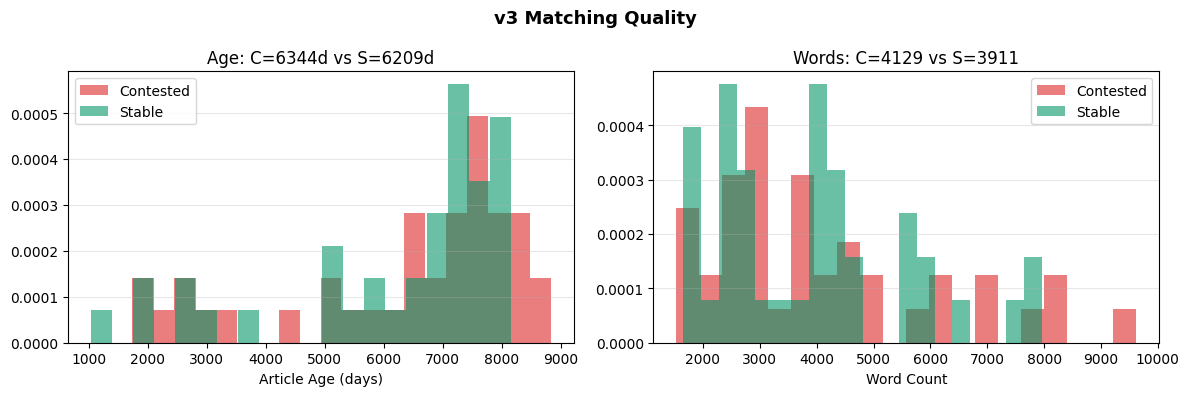

In [9]:
print(f"{'CONTESTED':<38} {'STABLE':<38} "
      f"{'DIST':>6}  {'AGE':>6}  {'WC%':>5}  TOPIC")
print("-" * 105)
for p in pairs_v3[:15]:
    c, s = p["contested"], p["stable"]
    tf = "OK" if p["same_topic"] else "!!"
    print(f"{c['title'][:36]:<38} {s['title'][:36]:<38} "
          f"{p['match_distance']:>6.3f}  {p['age_gap']:>6.0f}  "
          f"{p['wc_gap_pct']:>5.1f}%  {tf} {c['topic']} -> {s['topic']}")

c_ages  = [p["contested"]["age_days"]   for p in pairs_v3]
s_ages  = [p["stable"]["age_days"]      for p in pairs_v3]
c_words = [p["contested"]["word_count"] for p in pairs_v3]
s_words = [p["stable"]["word_count"]    for p in pairs_v3]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("v3 Matching Quality", fontsize=13, fontweight="bold")
for ax, (cv, sv, xlabel) in zip(axes, [
    (c_ages,  s_ages,  "Article Age (days)"),
    (c_words, s_words, "Word Count"),
]):
    ax.hist(cv, bins=20, alpha=0.6, color="#DC2626",
            label="Contested", density=True)
    ax.hist(sv, bins=20, alpha=0.6, color="#059669",
            label="Stable", density=True)
    ax.set_xlabel(xlabel)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

axes[0].set_title(
    f"Age: C={np.mean(c_ages):.0f}d vs S={np.mean(s_ages):.0f}d")
axes[1].set_title(
    f"Words: C={np.mean(c_words):.0f} vs S={np.mean(s_words):.0f}")
plt.tight_layout()
plt.savefig("v3_matching_quality.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Feature Extraction - v3
Resumes from CSV if v3_features.csv already exists.
Features:
- Linguistic: hedging density, definition ratio
- Structural: citation count, section count, unique editors, age, recency ratio
- Talk Page (now model features not just validation): revert count, talk words, talk editors
- topic_specific as regression control variable


In [10]:
HEDGING_WORDS = [
    "allegedly", "apparently", "arguably", "claims", "claimed",
    "reportedly", "supposedly", "some argue", "some suggest",
    "it is claimed", "it has been argued", "according to some",
    "disputed", "controversial", "contentious", "debated",
    "critics say", "critics argue", "opponents claim",
    "proponents argue", "others believe", "many believe",
]
DEFINITION_PATTERNS = [
    r'\bis (a|an|the)\b', r'\brefers to\b', r'\bdefined as\b',
    r'\bknown as\b', r'\bdescribed as\b', r'\bconsidered (a|an|the)\b',
]


def extract_features_v3(article):
    """Extract all features from one article."""
    text  = article.get("clean_text", "")
    words = text.lower().split()
    n     = len(words)
    if n == 0: return None

    sentences = [s.strip() for s in re.split(r'[.!?]+', text)
                 if len(s.strip()) > 10]
    n_sent    = max(len(sentences), 1)
    text_low  = text.lower()

    hedge_count = sum(text_low.count(w) for w in HEDGING_WORDS)
    hedging     = round(hedge_count / n * 1000, 4)

    def_sents = sum(1 for s in sentences
                    if any(re.search(p, s, re.IGNORECASE)
                           for p in DEFINITION_PATTERNS))
    def_ratio = round(def_sents / n_sent, 4)

    return {
        "title":           article["title"],
        "label":           article["label"],
        "label_name":      article["label_name"],
        "topic":           article["topic"],
        "topic_specific":  article.get("topic_specific"),
        # Linguistic
        "hedging_density": hedging,
        "def_ratio":       def_ratio,
        # Structural
        "citation_count":  article.get("citation_count", 0),
        "section_count":   article.get("section_count", 0),
        "unique_editors":  article.get("unique_editors", 0),
        "age_days":        article.get("age_days", 0),
        "recency_ratio":   article.get("recency_ratio", 0),
        # Talk page - model features
        "revert_count":    article.get("revert_count", 0),
        "talk_words":      article.get("talk_words", 0),
        "talk_editors":    article.get("talk_editors", 0),
        # Matching variables (reference only - not in model)
        "word_count":      article.get("word_count", n),
        "trends_avg":      article.get("trends_avg"),
    }


# Resume from CSV if it exists
if os.path.exists(V3_FEATURES_FILE):
    df_existing = pd.read_csv(V3_FEATURES_FILE)
    already_done = set(df_existing["title"].tolist())
    print(f"Loaded {len(df_existing)} existing feature rows from {V3_FEATURES_FILE}")
else:
    df_existing  = pd.DataFrame()
    already_done = set()
    print("No existing features file - extracting from scratch")

new_records = []
for p in pairs_v3:
    for article in [p["contested"], p["stable"]]:
        if article["title"] in already_done:
            continue
        feat = extract_features_v3(article)
        if feat:
            new_records.append(feat)

if new_records:
    df_new = pd.DataFrame(new_records)
    df = pd.concat([df_existing, df_new], ignore_index=True)
else:
    df = df_existing

df.to_csv(V3_FEATURES_FILE, index=False)
print(f"Feature matrix: {df.shape[0]} articles x {df.shape[1]} columns")
print(f"  Contested : {(df.label==0).sum()}")
print(f"  Stable    : {(df.label==1).sum()}")
df.head(4)


No existing features file - extracting from scratch
Feature matrix: 80 articles x 17 columns
  Contested : 40
  Stable    : 40


,title,label,label_name,topic,topic_specific,hedging_density,def_ratio,citation_count,section_count,unique_editors,age_days,recency_ratio,revert_count,talk_words,talk_editors,word_count,trends_avg
0,Lewis Namier,0,contested,geography,Geography.Regions.Europe.Europe*,0.5297,0.0000,40,11,213,7976,0.005,0,1498,26,2966,2.5
1,Sengkang MRT/LRT station,1,stable,geography,Geography.Regions.Asia.Southeast_Asia,0.0000,0.0440,45,11,196,7840,0.021,0,462,15,2583,NaN
2,New Jersey State Police,0,contested,politics_history,History_and_Society.Politics_and_government,1.5763,0.0451,55,26,230,5504,0.030,0,1381,18,4865,NaN
3,Wild and Free-Roaming Horses and Burros Act of...,1,stable,politics_history,History_and_Society.Politics_and_government,2.7043,0.0274,103,9,71,5439,0.007,0,2109,12,5744,NaN


## 9. Exploratory Analysis

In [11]:
FEATURE_COLS = [
    "hedging_density", "def_ratio", "citation_count",
    "section_count", "unique_editors", "age_days",
    "recency_ratio", "revert_count", "talk_words", "talk_editors"
]
LABELS = {
    "hedging_density": "Hedging Density",
    "def_ratio":       "Definition Ratio",
    "citation_count":  "Citation Count",
    "section_count":   "Section Count",
    "unique_editors":  "Unique Editors",
    "age_days":        "Article Age (days)",
    "recency_ratio":   "Edit Recency Ratio",
    "revert_count":    "Revert Count",
    "talk_words":      "Talk Word Count",
    "talk_editors":    "Talk Editors",
}

c_df = df[df.label == 0]
s_df = df[df.label == 1]

print(f"{'Feature':<25} {'Contested':>12} {'Stable':>12} {'Diff%':>8}")
print("-" * 62)
for col in FEATURE_COLS:
    cm, sm = c_df[col].mean(), s_df[col].mean()
    diff   = (cm - sm) / (sm + 1e-9) * 100
    print(f"{LABELS[col]:<25} {cm:>12.3f} {sm:>12.3f} "
          f"{'up' if diff > 0 else 'dn'}{abs(diff):>6.1f}%")


Feature                      Contested       Stable    Diff%
--------------------------------------------------------------
Hedging Density                  0.743        0.423 up  75.5%
Definition Ratio                 0.040        0.037 up   9.9%
Citation Count                  55.275       57.750 dn   4.3%
Section Count                   15.525       11.375 up  36.5%
Unique Editors                 181.750      124.325 up  46.2%
Article Age (days)            6343.800     6209.275 up   2.2%
Edit Recency Ratio               0.024        0.028 dn  14.3%
Revert Count                     0.600        0.350 up  71.4%
Talk Word Count               2657.450      640.450 up 314.9%
Talk Editors                    20.275       16.475 up  23.1%


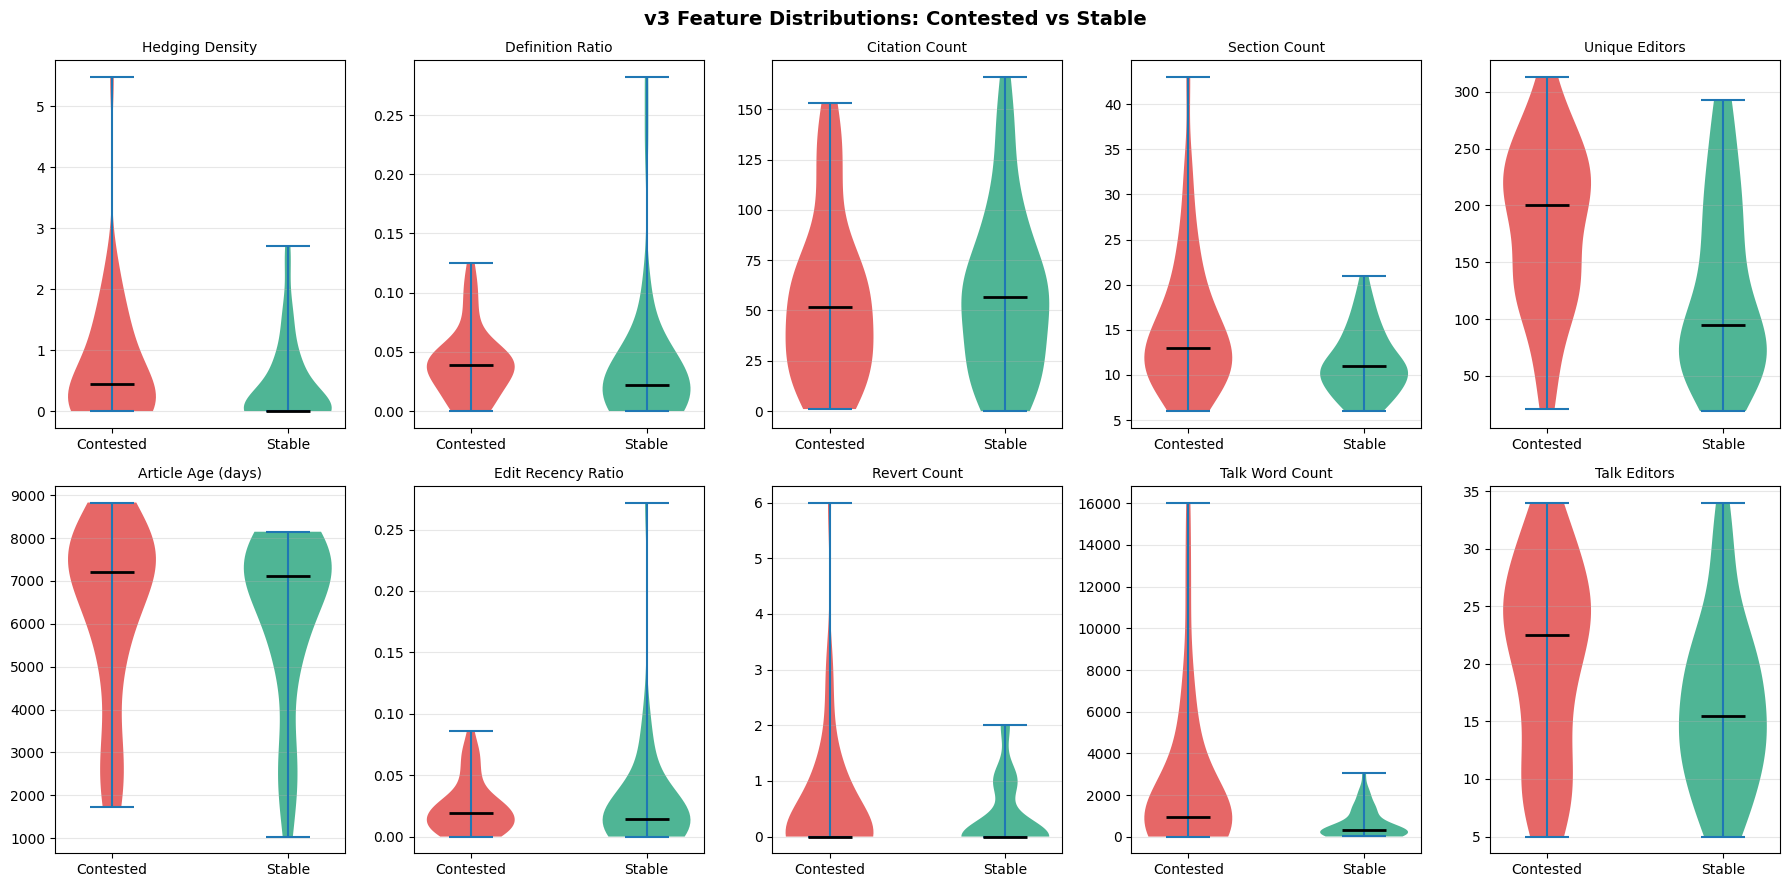

In [12]:
# Violin plots
n_cols = 5
fig, axes = plt.subplots(2, n_cols, figsize=(18, 9))
fig.suptitle("v3 Feature Distributions: Contested vs Stable",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    parts = ax.violinplot(
        [c_df[col].dropna().values, s_df[col].dropna().values],
        positions=[0, 1], showmedians=True)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)
    for j, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(["#DC2626", "#059669"][j])
        pc.set_alpha(0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Contested", "Stable"])
    ax.set_title(LABELS[col], fontsize=10)
    ax.grid(axis="y", alpha=0.3)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("v3_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Mann-Whitney U Tests

In [13]:
print("Mann-Whitney U - v3 Results\n")
print(f"{'Feature':<25} {'p-value':>9} {'Effect r':>9}  Direction  Sig?")
print("-" * 60)

mw_results = []
for col in FEATURE_COLS:
    cv = c_df[col].dropna().values
    sv = s_df[col].dropna().values
    if len(cv) < 3 or len(sv) < 3: continue
    u, p = mannwhitneyu(cv, sv, alternative="two-sided")
    z    = norm.ppf(1 - p / 2)
    r    = abs(z) / np.sqrt(len(cv) + len(sv))
    dire = "C > S" if cv.mean() > sv.mean() else "C < S"
    sig  = "YES" if p < 0.05 else ("~" if p < 0.10 else "no")
    print(f"{LABELS[col]:<25} {p:>9.4f} {r:>9.3f}  {dire}      {sig}")
    mw_results.append({
        "feature": col, "p": p, "r": r,
        "direction": dire, "sig": p < 0.05
    })

print("\nYES = p<0.05   ~ = p<0.10   no = not significant")


Mann-Whitney U - v3 Results

Feature                     p-value  Effect r  Direction  Sig?
------------------------------------------------------------
Hedging Density              0.0803     0.196  C > S      ~
Definition Ratio             0.0316     0.240  C > S      YES
Citation Count               0.8286     0.024  C < S      no
Section Count                0.0076     0.299  C > S      YES
Unique Editors               0.0010     0.367  C > S      YES
Article Age (days)           0.4705     0.081  C > S      no
Edit Recency Ratio           0.5375     0.069  C < S      no
Revert Count                 0.5345     0.069  C > S      no
Talk Word Count              0.0007     0.377  C > S      YES
Talk Editors                 0.0325     0.239  C > S      YES

YES = p<0.05   ~ = p<0.10   no = not significant


## 11. Logistic Regression - v3

In [14]:
MODEL_FEATURES = [
    "hedging_density", "def_ratio",
    "citation_count", "section_count",
    "unique_editors", "age_days", "recency_ratio",
    "revert_count", "talk_words", "talk_editors",
]

df_m   = df[MODEL_FEATURES + ["label"]].dropna()
X      = df_m[MODEL_FEATURES].values
y      = df_m["label"].values
scaler = StandardScaler()
Xs     = scaler.fit_transform(X)

cv_s   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model  = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=42)

f1s    = cross_val_score(model, Xs, y, cv=cv_s, scoring="f1_macro")
accs   = cross_val_score(model, Xs, y, cv=cv_s, scoring="accuracy")
base   = max(y.mean(), 1 - y.mean())

print("5-fold Cross-Validation - v3")
print(f"  F1 (macro) : {f1s.mean():.3f} +/- {f1s.std():.3f}")
print(f"  Accuracy   : {accs.mean():.3f} +/- {accs.std():.3f}")
print(f"  Baseline   : {base:.3f}")
print(f"  Improvement: {accs.mean() - base:+.3f}")


5-fold Cross-Validation - v3
  F1 (macro) : 0.730 +/- 0.110
  Accuracy   : 0.738 +/- 0.108
  Baseline   : 0.500
  Improvement: +0.238


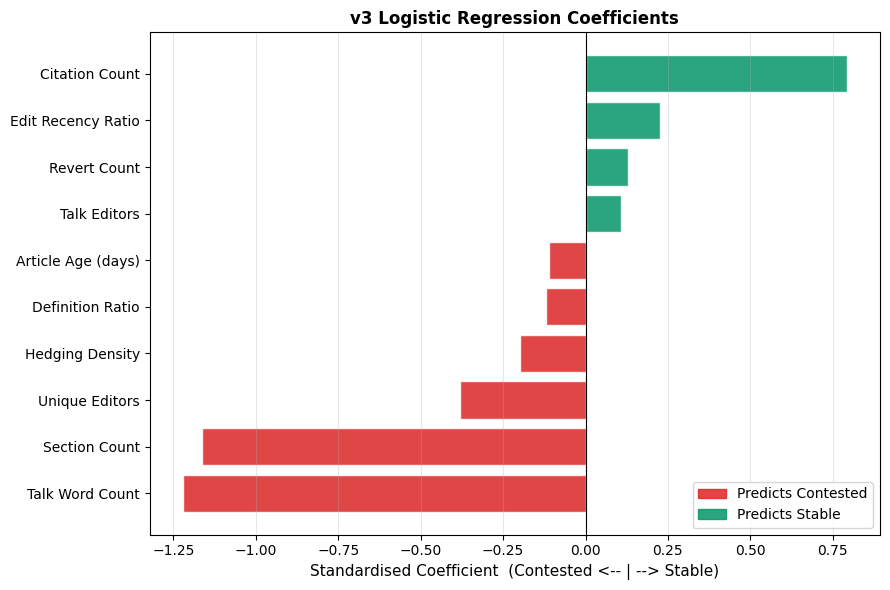


Coefficients:
  Talk Word Count              -1.2215  <-- Contested
  Section Count                -1.1630  <-- Contested
  Unique Editors               -0.3808  <-- Contested
  Hedging Density              -0.1979  <-- Contested
  Definition Ratio             -0.1200  <-- Contested
  Article Age (days)           -0.1097  <-- Contested
  Talk Editors                 +0.1085  --> Stable
  Revert Count                 +0.1295  --> Stable
  Edit Recency Ratio           +0.2253  --> Stable
  Citation Count               +0.7926  --> Stable


In [15]:
model.fit(Xs, y)
coef_df = pd.DataFrame({
    "feature":     [LABELS[f] for f in MODEL_FEATURES],
    "coefficient": model.coef_[0],
}).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 6))
colors  = ["#DC2626" if c < 0 else "#059669"
           for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"],
        color=colors, alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(
    "Standardised Coefficient  (Contested <-- | --> Stable)", fontsize=11)
ax.set_title("v3 Logistic Regression Coefficients",
             fontsize=12, fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color="#DC2626", alpha=0.85, label="Predicts Contested"),
    mpatches.Patch(color="#059669", alpha=0.85, label="Predicts Stable"),
], loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("v3_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCoefficients:")
for _, row in coef_df.iterrows():
    arrow = "<-- Contested" if row["coefficient"] < 0 else "--> Stable"
    print(f"  {row['feature']:<28} {row['coefficient']:>+7.4f}  {arrow}")


## 12. v3 Summary

In [16]:
print("=" * 65)
print("ITERATION 3 SUMMARY")
print("=" * 65)

print(f"\nDataset")
print(f"  Matched pairs    : {len(pairs_v3)}")
print(f"  Rejected         : {len(rejected)}")
print(f"  Same-topic pairs : {same_topic}/{len(pairs_v3)}")

print(f"\nMatching Quality")
print(f"  Avg distance : {avg_dist:.3f}")
print(f"  Avg age gap  : {avg_age_gap:.0f} days")
print(f"  Avg WC gap   : {avg_wc_gap:.1f}%")

print(f"\nModel Performance")
print(f"  F1 macro  : {f1s.mean():.3f} +/- {f1s.std():.3f}")
print(f"  Accuracy  : {accs.mean():.3f} +/- {accs.std():.3f}")
print(f"  Baseline  : {base:.3f}")

sig_feats = [r for r in mw_results if r["sig"]]
not_sig   = [r for r in mw_results if not r["sig"]]

print(f"\nSignificant features (p<0.05): {len(sig_feats)}")
for r in sorted(sig_feats, key=lambda x: x["r"], reverse=True):
    print(f"  {LABELS.get(r['feature'], r['feature']):<28} "
          f"p={r['p']:.3f}  r={r['r']:.3f}  {r['direction']}")

print(f"\nNot significant: {len(not_sig)}")
for r in not_sig:
    print(f"  {LABELS.get(r['feature'], r['feature']):<28} p={r['p']:.3f}")

print(f"\nFiles saved")
print(f"  {V3_CONTESTED_FILE}")
print(f"  {V3_STABLE_FILE}")
print(f"  {V3_PAIRS_FILE}")
print(f"  {V3_FEATURES_FILE}")
print(f"  v3_matching_quality.png")
print(f"  v3_feature_distributions.png")
print(f"  v3_coefficients.png")
print("=" * 65)


ITERATION 3 SUMMARY

Dataset
  Matched pairs    : 40
  Rejected         : 10
  Same-topic pairs : 31/40

Matching Quality
  Avg distance : 0.119
  Avg age gap  : 298 days
  Avg WC gap   : 8.9%

Model Performance
  F1 macro  : 0.730 +/- 0.110
  Accuracy  : 0.738 +/- 0.108
  Baseline  : 0.500

Significant features (p<0.05): 5
  Talk Word Count              p=0.001  r=0.377  C > S
  Unique Editors               p=0.001  r=0.367  C > S
  Section Count                p=0.008  r=0.299  C > S
  Definition Ratio             p=0.032  r=0.240  C > S
  Talk Editors                 p=0.032  r=0.239  C > S

Not significant: 5
  Hedging Density              p=0.080
  Citation Count               p=0.829
  Article Age (days)           p=0.470
  Edit Recency Ratio           p=0.538
  Revert Count                 p=0.534

Files saved
  v3_contested.json
  v3_stable_pool.json
  v3_matched_pairs.json
  v3_features.csv
  v3_matching_quality.png
  v3_feature_distributions.png
  v3_coefficients.png


---
## Files Generated (all prefixed v3_ - v2 files untouched)

| File | Contents |
|---|---|
| v3_contested.json | Contested articles |
| v3_stable_pool.json | Stable pool (Good Articles, verified no dispute history) |
| v3_matched_pairs.json | Matched pairs |
| v3_features.csv | Feature matrix - resumes if interrupted |
| v3_good_article_titles_en.json | Cached Good Article titles |
| v3_template_titles_*.json | Cached template title lists (7-day expiry) |
| v3_trends_cache_*.json | Google Trends cache |
| v3_matching_quality.png | Distribution plots |
| v3_feature_distributions.png | Violin plots |
| v3_coefficients.png | Regression coefficient chart |

## Key Changes from v2

- Same MIN_WORDS (1500) and MIN_EDITORS (15) for both groups
- Rate limit wait 180s instead of 90s
- Title caches saved to file - no re-fetching on resume
- Feature extraction resumes from CSV - skips already processed articles
- No em dashes anywhere
- Lift Wing topic model confirmed working for EN and DE
- topic_specific field saved for regression control variable
